In [6]:
# ----------------------------
# 01: Imports
# ----------------------------
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import random
import folium
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [8]:
# ----------------------------
# 02: Seed for reproducibility
# ----------------------------
np.random.seed(42)
random.seed(42)

In [9]:
# ----------------------------
# 03: Parameters
# ----------------------------
num_records = 1000  # can scale as needed
districts = ["Kampala", "Gulu", "Arua", "Lira"]

# Villages / Cells per district
district_villages = {
    "Arua": ["Awindiri", "Mvara", "Onduparaka", "Jiako", "Pajulu"],
    "Gulu": ["Bardege", "Laroo", "Pece", "Kanyagoga", "Layibi"],
    "Lira": ["Adyel", "Ojwina", "Ireda", "Ngetta", "Railway"],
    "Kampala": ["Kisenyi", "Bukoto I", "Bukoto II", "Kiwatule", "Kansanga", "Kasubi"]
}

# GPS coordinates per village
village_coords = {
    "Arua": {
        "Awindiri": (3.0300, 30.9100),
        "Onduparaka": (3.0400, 30.8900),
        "Jiako": (3.0250, 30.9050),
        "Mvara": (3.0320, 30.9150),
        "Pajulu": (3.0380, 30.9200),
        "District Center": (3.0353, 30.9108)
    },
    "Gulu": {
        "Bardege": (2.7850, 32.2716),
        "Layibi": (2.7407, 32.2967),
        "Pece": (2.7700, 32.2900),
        "Kanyagoga": (2.7750, 32.2800),
        "Laroo": (2.7800, 32.2850),
        "District Center": (2.7817, 32.2992)
    },
    "Lira": {
        "Adyel": (2.2660, 32.8927),
        "Ireda": (2.2500, 32.9100),
        "Ngetta": (2.2600, 32.8950),
        "Ojwina": (2.2550, 32.9050),
        "Railway": (2.2450, 32.9000),
        "District Center": (2.2472, 32.9000)
    },
    "Kampala": {
        "Kisenyi": (0.3196, 32.5923),
        "Kansanga": (0.2897, 32.6070),
        "Bukoto I": (0.3350, 32.6000),
        "Bukoto II": (0.3360, 32.6050),
        "Kiwatule": (0.3220, 32.6100),
        "Kasubi": (0.3100, 32.5800),
        "City Center": (0.3136, 32.5811)
    }
}

In [10]:
# ----------------------------
# 04: Generate random dates (last 14 days)
# ----------------------------
today = datetime.today()
dates = [today - timedelta(days=random.randint(0,14)) for _ in range(num_records)]


In [11]:
# ----------------------------
# 05: Random districts & villages
# ----------------------------
district_choices = [random.choice(districts) for _ in range(num_records)]
village_choices = [random.choice(district_villages[d]) for d in district_choices]


In [12]:
# ----------------------------
# 06: Patient ages
# ----------------------------
ages = np.random.randint(0, 81, size=num_records)


In [13]:
# ----------------------------
# 07: Mosquito net use probabilities per district
# ----------------------------
net_probs = {"Arua":0.5, "Gulu":0.6, "Lira":0.55, "Kampala":0.8}
net_use = [np.random.choice(["yes","no"], p=[net_probs[d], 1-net_probs[d]]) for d in district_choices]


In [14]:
# ----------------------------
# 08: Fever probability per district + week
# ----------------------------
weeks = [ (today - timedelta(days=random.randint(0,14))).isocalendar().week for _ in range(num_records)]
fever = []
for d, w in zip(district_choices, weeks):
    base_prob = 0.3
    if d in ["Arua","Lira"] and w in [10,11]:
        base_prob += 0.15
    elif d=="Gulu" and w==10:
        base_prob += 0.10
    elif d=="Kampala":
        base_prob -= 0.05
    fever.append(np.random.choice(["yes","no"], p=[base_prob, 1-base_prob]))


In [15]:
# ----------------------------
# 09: Malaria test result per district & fever
# ----------------------------
malaria = []
for f, d in zip(fever, district_choices):
    if f=="yes":
        if d=="Arua":
            p_pos = 0.35
        elif d=="Gulu":
            p_pos = 0.30
        elif d=="Lira":
            p_pos = 0.40
        else: # Kampala
            p_pos = 0.20
        p_neg = 1 - p_pos - 0.1
        malaria.append(np.random.choice(["positive","negative","not_tested"], p=[p_pos,p_neg,0.1]))
    else:
        malaria.append(np.random.choice(["positive","negative","not_tested"], p=[0.05,0.75,0.2]))


In [16]:
# ----------------------------
# Step 7: Malaria test result (conditional)
# ----------------------------
malaria = []
for f in fever:
    if f == "yes":
        malaria.append(np.random.choice(["positive", "negative", "not_tested"], p=[0.5, 0.4, 0.1]))
    else:
        malaria.append(np.random.choice(["positive", "negative", "not_tested"], p=[0.1, 0.7, 0.2]))


In [16]:
# ----------------------------
# 10: Rainfall last week (mm) and sanitation
# ----------------------------
rainfall = np.round(np.random.uniform(0,150, size=num_records),1)
sanitation = np.random.choice(["yes","no"], size=num_records, p=[0.8,0.2])

In [17]:
# ----------------------------
# 11: GPS coordinates + accuracy
# ----------------------------
gps_coords = []
gps_accuracy = []
for d, v in zip(district_choices, village_choices):
    lat, lon = village_coords[d][v]
    lat += np.random.uniform(-0.002,0.002)
    lon += np.random.uniform(-0.002,0.002)
    gps_coords.append(f"{lat},{lon}")
    gps_accuracy.append(np.random.randint(5,51))

In [18]:
# ----------------------------
# 12: Assemble DataFrame
# ----------------------------
df = pd.DataFrame({
    "report_date": dates,
    "district": district_choices,
    "village": village_choices,
    "patient_age": ages,
    "fever_last_48h": fever,
    "malaria_test_result": malaria,
    "mosquito_net_use": net_use,
    "rainfall_last_week": rainfall,
    "sanitation_access": sanitation,
    "gps_location": gps_coords,
    "gps_accuracy_m": gps_accuracy,
    "week": weeks
})

In [19]:
# ----------------------------
# 13: Preview sample
# ----------------------------
df.head()

,report_date,district,village,patient_age,fever_last_48h,malaria_test_result,mosquito_net_use,rainfall_last_week,sanitation_access,gps_location,gps_accuracy_m,week
0,2026-03-05 09:03:47.973402,Kampala,Kasubi,51,no,not_tested,yes,145.5,yes,"0.308353587868587,32.57936890209911",7,11
1,2026-03-14 09:03:47.973402,Gulu,Kanyagoga,14,no,negative,no,64.7,yes,"2.775518734381037,32.27966464378562",17,10
2,2026-03-15 09:03:47.973402,Lira,Ojwina,71,yes,positive,no,52.1,no,"2.2566244037147216,32.903550936395554",27,10
3,2026-03-04 09:03:47.973402,Arua,Pajulu,60,yes,negative,yes,7.6,yes,"3.0371259092098035,30.918280274782887",45,10
4,2026-03-11 09:03:47.973402,Arua,Onduparaka,20,yes,negative,yes,7.9,no,"3.0406317979431265,30.890909908311986",6,11


In [24]:
gps_coords = []
gps_accuracy = []

for d, v in zip(district_choices, village_choices):
    lat, lon = village_coords[d][v]
    # Add small random jitter for realism (±0.002 deg ~ 200 m)
    lat += np.random.uniform(-0.002, 0.002)
    lon += np.random.uniform(-0.002, 0.002)
    gps_coords.append(f"{lat},{lon}")
    
    # Simulate accuracy between 5m and 50m
    gps_accuracy.append(np.random.randint(5, 51))

In [25]:
# ----------------------------
# Step 12: Assemble DataFrame
# ----------------------------
df = pd.DataFrame({
    "report_date": dates,
    "district": district_choices,
    "village": village_choices,
    "patient_age": ages,
    "fever_last_48h": fever,
    "malaria_test_result": malaria,
    "mosquito_net_use": net_use,
    "rainfall_last_week": rainfall,
    "sanitation_access": sanitation,
    "gps_location": gps_coords,
    "gps_accuracy_m": gps_accuracy
})


In [26]:
# ----------------------------
# Step 13: Preview sample
# ----------------------------
df.head()

,report_date,district,village,patient_age,fever_last_48h,malaria_test_result,mosquito_net_use,rainfall_last_week,sanitation_access,gps_location,gps_accuracy_m
0,2026-03-05 08:45:38.728087,Kampala,Kansanga,2,no,negative,no,94.6,no,"0.2916821720720803,32.607842965610374",45
1,2026-03-14 08:45:38.728087,Lira,Ojwina,73,yes,not_tested,yes,131.5,no,"2.2566538504117473,32.904250390459104",17
2,2026-03-15 08:45:38.728087,Lira,Adyel,67,no,not_tested,yes,24.3,yes,"2.264103625125459,32.891177195673336",11
3,2026-03-04 08:45:38.728087,Lira,Ojwina,13,no,negative,no,72.5,yes,"2.2547571686209897,32.906188838673714",40
4,2026-03-11 08:45:38.728087,Arua,Mvara,86,yes,positive,yes,146.8,yes,"3.0311109363548625,30.91371967773065",15


In [20]:
# ----------------------------
# 13: Save CSV
# ----------------------------
df.to_csv("../data/surveillance_data.csv", index=False)
print("Dataset saved to ../data/surveillance_data.csv with GPS accuracy included!")

Dataset saved to ../data/surveillance_data.csv with GPS accuracy included!


# ETL pipeline

In [21]:
import pandas as pd
from sqlalchemy import create_engine

In [22]:
# Load CSV
df = pd.read_csv("../data/surveillance_data.csv")
df['report_date'] = pd.to_datetime(df['report_date'])

In [23]:
# Connect to SQLite
engine = create_engine("sqlite:///../database/surveillance.db")

In [24]:
# Load into table
df.to_sql("surveillance_reports", engine, if_exists="replace", index=False)
print("Data loaded into SQLite database at ../database/surveillance.db")

Data loaded into SQLite database at ../database/surveillance.db


In [25]:
# Quick check
pd.read_sql("SELECT * FROM surveillance_reports LIMIT 5", engine)

,report_date,district,village,patient_age,fever_last_48h,malaria_test_result,mosquito_net_use,rainfall_last_week,sanitation_access,gps_location,gps_accuracy_m,week
0,2026-03-05 09:03:47.973402,Kampala,Kasubi,51,no,not_tested,yes,145.5,yes,"0.308353587868587,32.57936890209911",7,11
1,2026-03-14 09:03:47.973402,Gulu,Kanyagoga,14,no,negative,no,64.7,yes,"2.775518734381037,32.27966464378562",17,10
2,2026-03-15 09:03:47.973402,Lira,Ojwina,71,yes,positive,no,52.1,no,"2.2566244037147216,32.903550936395554",27,10
3,2026-03-04 09:03:47.973402,Arua,Pajulu,60,yes,negative,yes,7.6,yes,"3.0371259092098035,30.918280274782887",45,10
4,2026-03-11 09:03:47.973402,Arua,Onduparaka,20,yes,negative,yes,7.9,no,"3.0406317979431265,30.890909908311986",6,11


# Analytics

Weekly fever trend per district

In [26]:
df['week'] = df['report_date'].dt.isocalendar().week
weekly_trend = df.groupby(['district','week'])['fever_last_48h'].apply(lambda x: (x=='yes').sum()).reset_index(name='fever_cases')
weekly_trend

,district,week,fever_cases
0,Arua,9,10
1,Arua,10,47
2,Arua,11,59
3,Gulu,9,7
4,Gulu,10,33
5,Gulu,11,34
6,Kampala,9,6
7,Kampala,10,23
8,Kampala,11,26
9,Lira,9,9


Malaria positivity rate per district

In [27]:
malaria_df = df[df['malaria_test_result'] != 'not_tested']
malaria_rate = malaria_df.groupby('district')['malaria_test_result'].apply(lambda x: (x=='positive').sum()/len(x)*100).reset_index(name='malaria_positive_rate')
malaria_rate

,district,malaria_positive_rate
0,Arua,20.704846
1,Gulu,18.435754
2,Kampala,9.090909
3,Lira,25.446429


Mosquito net usage effect

In [28]:
net_effect = df.groupby('mosquito_net_use')['malaria_test_result'].apply(lambda x: (x=='positive').sum()/len(x)*100).reset_index(name='malaria_positive_rate')
net_effect

,mosquito_net_use,malaria_positive_rate
0,no,17.948718
1,yes,14.098361


Basic map visualization

In [29]:
import folium

# Center map at Uganda
m = folium.Map(location=[1.5, 32.5], zoom_start=6)

# Plot all points
for idx, row in df.iterrows():
    lat, lon = map(float, row['gps_location'].split(','))
    folium.CircleMarker(location=[lat, lon],
                        radius=3,
                        color='red' if row['fever_last_48h']=='yes' else 'blue',
                        fill=True).add_to(m)
m

In [30]:
# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("../data/surveillance_data.csv")
df['report_date'] = pd.to_datetime(df['report_date'])

In [31]:
# ----------------------------
# Weekly fever trends per district
# ----------------------------
df['week'] = df['report_date'].dt.isocalendar().week
weekly_trend = df.groupby(['district','week'])['fever_last_48h'].apply(lambda x: (x=='yes').sum()).reset_index(name='fever_cases')
print("Weekly Fever Trends:")
display(weekly_trend.head(10))


Weekly Fever Trends:


,district,week,fever_cases
0,Arua,9,10
1,Arua,10,47
2,Arua,11,59
3,Gulu,9,7
4,Gulu,10,33
5,Gulu,11,34
6,Kampala,9,6
7,Kampala,10,23
8,Kampala,11,26
9,Lira,9,9


In [32]:
# ----------------------------
# Malaria positivity rate per district
# ----------------------------
malaria_df = df[df['malaria_test_result'] != 'not_tested']
malaria_rate = malaria_df.groupby('district')['malaria_test_result'].apply(lambda x: (x=='positive').sum()/len(x)*100).reset_index(name='malaria_positive_rate')
print("Malaria Positivity Rate by District:")
display(malaria_rate)

Malaria Positivity Rate by District:


,district,malaria_positive_rate
0,Arua,20.704846
1,Gulu,18.435754
2,Kampala,9.090909
3,Lira,25.446429


In [33]:

# ----------------------------
# Mosquito net effect on malaria positivity
# ----------------------------
net_effect = df.groupby('mosquito_net_use')['malaria_test_result'].apply(lambda x: (x=='positive').sum()/len(x)*100).reset_index(name='malaria_positive_rate')
print("Malaria Positivity vs Mosquito Net Use:")
display(net_effect)


Malaria Positivity vs Mosquito Net Use:


,mosquito_net_use,malaria_positive_rate
0,no,17.948718
1,yes,14.098361


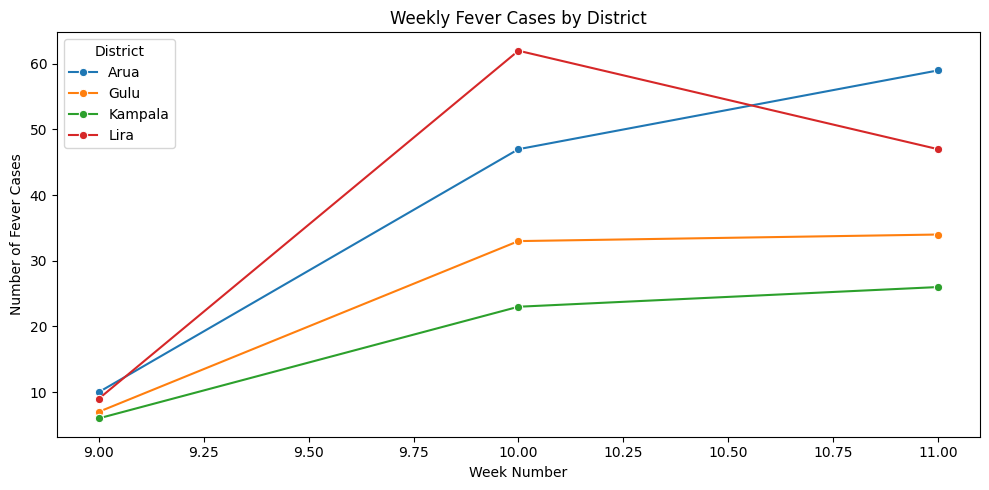

In [34]:
# ----------------------------
# Simple line plot: weekly fever trend
# ----------------------------
plt.figure(figsize=(10,5))
sns.lineplot(data=weekly_trend, x='week', y='fever_cases', hue='district', marker='o')
plt.title("Weekly Fever Cases by District")
plt.xlabel("Week Number")
plt.ylabel("Number of Fever Cases")
plt.legend(title="District")
plt.tight_layout()
plt.show()

C:\Users\asian\AppData\Local\Temp\ipykernel_7576\929470725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=malaria_rate, x='district', y='malaria_positive_rate', palette='viridis')


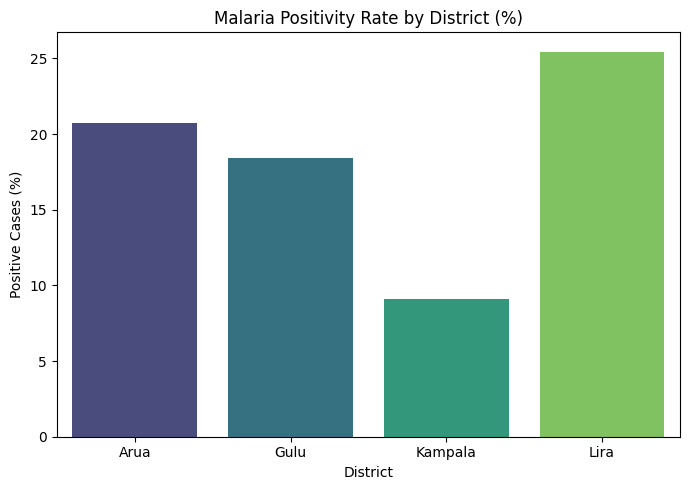

In [35]:
# ----------------------------
# Bar plot: Malaria positivity by district
# ----------------------------
plt.figure(figsize=(7,5))
sns.barplot(data=malaria_rate, x='district', y='malaria_positive_rate', palette='viridis')
plt.title("Malaria Positivity Rate by District (%)")
plt.ylabel("Positive Cases (%)")
plt.xlabel("District")
plt.tight_layout()
plt.show()

In [36]:
# ----------------------------
# Map: Fever case locations
# ----------------------------
# Center map roughly at Uganda
uganda_map = folium.Map(location=[1.5, 32.5], zoom_start=6)

# Add points
for idx, row in df.iterrows():
    lat, lon = map(float, row['gps_location'].split(','))
    color = 'red' if row['fever_last_48h']=='yes' else 'blue'
    folium.CircleMarker(
        location=[lat, lon],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.7
    ).add_to(uganda_map)


In [37]:
# Display map in notebook
uganda_map

In [38]:
# Save map for sharing
uganda_map.save("../data/uganda_fever_map.html")
print("Map saved as ../data/uganda_fever_map.html")

Map saved as ../data/uganda_fever_map.html


===== Key Metrics =====
Total Reports: 1000
Fever Cases: 363
Malaria Tests Conducted: 839
Malaria Positive Cases: 156


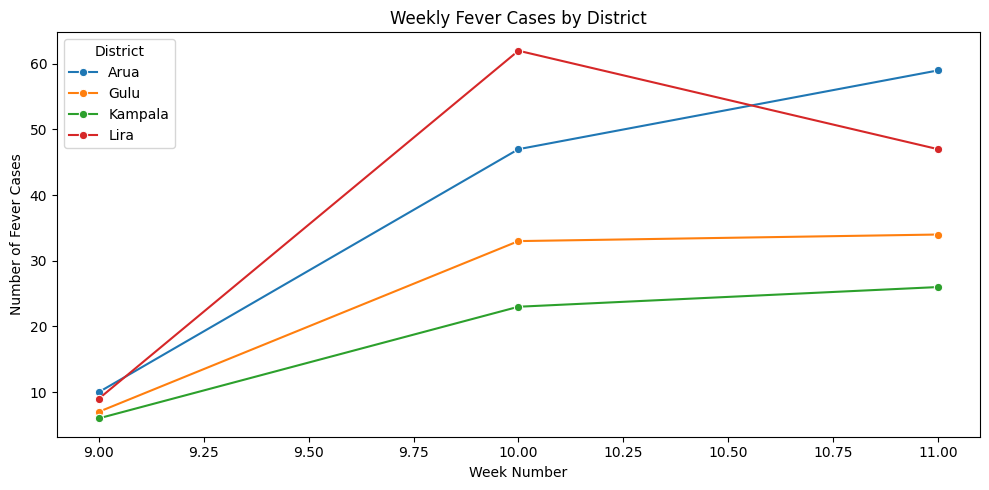

C:\Users\asian\AppData\Local\Temp\ipykernel_7576\1693963476.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=malaria_rate, x='district', y='malaria_positive_rate', palette='viridis')


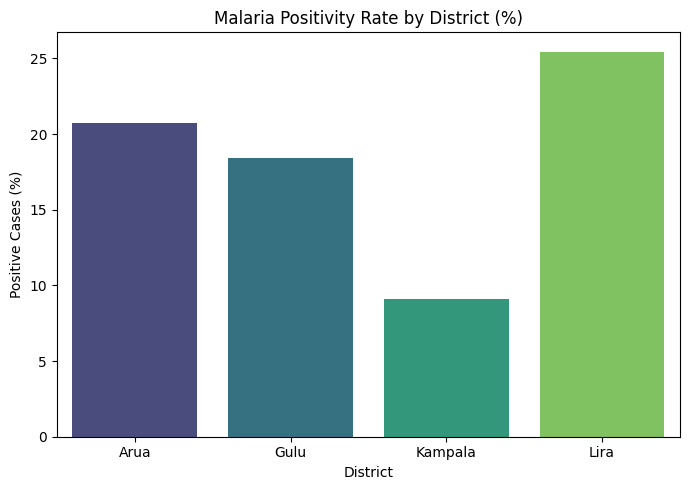


===== Mosquito Net Effect =====


,mosquito_net_use,malaria_positive_rate
0,no,17.948718
1,yes,14.098361



Interactive map saved as ../data/uganda_fever_map.html
Cleaned dataset saved as ../data/surveillance_data_portfolio.csv


In [39]:
# ----------------------------
# Portfolio-Ready Analytics & Summary
# ----------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Load simulated data
df = pd.read_csv("../data/surveillance_data.csv")
df['report_date'] = pd.to_datetime(df['report_date'])
df['week'] = df['report_date'].dt.isocalendar().week

# ----------------------------
# 1. Key metrics
# ----------------------------
total_reports = len(df)
total_fever = (df['fever_last_48h']=='yes').sum()
total_malaria_tested = df[df['malaria_test_result']!='not_tested']
total_malaria_positive = (total_malaria_tested['malaria_test_result']=='positive').sum()

print("===== Key Metrics =====")
print(f"Total Reports: {total_reports}")
print(f"Fever Cases: {total_fever}")
print(f"Malaria Tests Conducted: {len(total_malaria_tested)}")
print(f"Malaria Positive Cases: {total_malaria_positive}")

# ----------------------------
# 2. Weekly Fever Trends per District
# ----------------------------
weekly_trend = df.groupby(['district','week'])['fever_last_48h'].apply(lambda x: (x=='yes').sum()).reset_index(name='fever_cases')

plt.figure(figsize=(10,5))
sns.lineplot(data=weekly_trend, x='week', y='fever_cases', hue='district', marker='o')
plt.title("Weekly Fever Cases by District")
plt.xlabel("Week Number")
plt.ylabel("Number of Fever Cases")
plt.legend(title="District")
plt.tight_layout()
plt.show()

# ----------------------------
# 3. Malaria Positivity Rate per District
# ----------------------------
malaria_df = df[df['malaria_test_result'] != 'not_tested']
malaria_rate = malaria_df.groupby('district')['malaria_test_result'].apply(lambda x: (x=='positive').sum()/len(x)*100).reset_index(name='malaria_positive_rate')

plt.figure(figsize=(7,5))
sns.barplot(data=malaria_rate, x='district', y='malaria_positive_rate', palette='viridis')
plt.title("Malaria Positivity Rate by District (%)")
plt.ylabel("Positive Cases (%)")
plt.xlabel("District")
plt.tight_layout()
plt.show()

# ----------------------------
# 4. Mosquito Net Effect on Malaria
# ----------------------------
net_effect = df.groupby('mosquito_net_use')['malaria_test_result'].apply(lambda x: (x=='positive').sum()/len(x)*100).reset_index(name='malaria_positive_rate')
print("\n===== Mosquito Net Effect =====")
display(net_effect)

# ----------------------------
# 5. Interactive Map
# ----------------------------
uganda_map = folium.Map(location=[1.5, 32.5], zoom_start=6)

for idx, row in df.iterrows():
    lat, lon = map(float, row['gps_location'].split(','))
    color = 'red' if row['fever_last_48h']=='yes' else 'blue'
    folium.CircleMarker(
        location=[lat, lon],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.7
    ).add_to(uganda_map)

# Display map
uganda_map

# Save map for sharing
uganda_map.save("../data/uganda_fever_map.html")
print("\nInteractive map saved as ../data/uganda_fever_map.html")

# ----------------------------
# 6. Save cleaned CSV for portfolio
# ----------------------------
df.to_csv("../data/surveillance_data_portfolio.csv", index=False)
print("Cleaned dataset saved as ../data/surveillance_data_portfolio.csv")

In [40]:
# ----------------------------
# FINAL: Save all outputs for portfolio
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# ----------------------------
# 1. Ensure folder exists
# ----------------------------
import os
if not os.path.exists("../data"):
    os.makedirs("../data")

# ----------------------------
# 2. Weekly Fever Trend plot
# ----------------------------
plt.figure(figsize=(10,5))
sns.lineplot(data=weekly_trend, x='week', y='fever_cases', hue='district', marker='o')
plt.title("Weekly Fever Cases by District")
plt.xlabel("Week Number")
plt.ylabel("Number of Fever Cases")
plt.legend(title="District")
plt.tight_layout()
plt.savefig("../data/weekly_fever_trend.png", dpi=300)
plt.close()
print("Saved plot: weekly_fever_trend.png")

# ----------------------------
# 3. Malaria Positivity Rate plot
# ----------------------------
plt.figure(figsize=(7,5))
sns.barplot(data=malaria_rate, x='district', y='malaria_positive_rate', palette='viridis')
plt.title("Malaria Positivity Rate by District (%)")
plt.ylabel("Positive Cases (%)")
plt.xlabel("District")
plt.tight_layout()
plt.savefig("../data/malaria_positivity_rate.png", dpi=300)
plt.close()
print("Saved plot: malaria_positivity_rate.png")

# ----------------------------
# 4. Mosquito Net Effect CSV
# ----------------------------
net_effect.to_csv("../data/mosquito_net_effect.csv", index=False)
print("Saved table: mosquito_net_effect.csv")

# ----------------------------
# 5. Interactive Map
# ----------------------------
uganda_map = folium.Map(location=[1.5, 32.5], zoom_start=6)
for idx, row in df.iterrows():
    lat, lon = map(float, row['gps_location'].split(','))
    color = 'red' if row['fever_last_48h']=='yes' else 'blue'
    folium.CircleMarker(location=[lat, lon],
                        radius=3, color=color,
                        fill=True, fill_opacity=0.7).add_to(uganda_map)
uganda_map.save("../data/uganda_fever_map.html")
print("Saved interactive map: uganda_fever_map.html")

# ----------------------------
# 6. Cleaned Dataset CSV
# ----------------------------
df.to_csv("../data/surveillance_data_portfolio.csv", index=False)
print("Saved dataset: surveillance_data_portfolio.csv")

print("\nAll portfolio-ready outputs saved in ../data/")

Saved plot: weekly_fever_trend.png


C:\Users\asian\AppData\Local\Temp\ipykernel_7576\3358761884.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=malaria_rate, x='district', y='malaria_positive_rate', palette='viridis')


Saved plot: malaria_positivity_rate.png
Saved table: mosquito_net_effect.csv
Saved interactive map: uganda_fever_map.html
Saved dataset: surveillance_data_portfolio.csv

All portfolio-ready outputs saved in ../data/


ETL: Load cleaned CSV into SQLite

In [41]:
# ----------------------------
# 1. Ensure database folder exists
# ----------------------------
if not os.path.exists("../database"):
    os.makedirs("../database")

# ----------------------------
# 2. Create SQLite engine
# ----------------------------
db_path = "../database/surveillance.db"
engine = create_engine(f"sqlite:///{db_path}")

# ----------------------------
# 3. Load CSV into database
# ----------------------------
df = pd.read_csv("../data/surveillance_data_portfolio.csv")
df['report_date'] = pd.to_datetime(df['report_date'])

# Write to table 'surveillance_reports', replace if it exists
df.to_sql("surveillance_reports", con=engine, if_exists="replace", index=False)
print(f"ETL complete: {len(df)} records loaded into {db_path} in table 'surveillance_reports'")

# ----------------------------
# 4. Test query
# ----------------------------
test_query = pd.read_sql("SELECT district, COUNT(*) as total_reports FROM surveillance_reports GROUP BY district", engine)
print("\nSample check - total reports per district:")
display(test_query)

ETL complete: 1000 records loaded into ../database/surveillance.db in table 'surveillance_reports'

Sample check - total reports per district:


,district,total_reports
0,Arua,272
1,Gulu,218
2,Kampala,247
3,Lira,263
